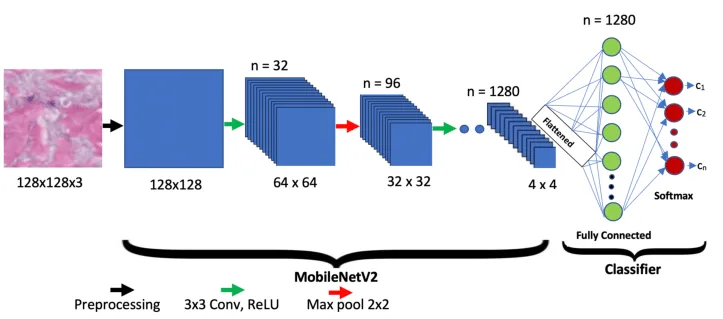

* ***Pre-trained MobileNetV2 Model***

**MobileNetV2** is a lightweight, efficient convolutional neural network architecture designed for mobile and embedded vision applications. It is the second version of the MobileNet family, and it offers improved performance and reduced computational complexity through the use of *inverted residual blocks* and *linear bottlenecks*.

A *pre-trained MobileNetV2 model* has been trained on the ImageNet dataset, which contains over one million images across 1,000 categories. As a result, it has already learned general image features such as edges, textures, and shapes. This pre-trained knowledge can be transferred to new tasks, eliminating the need to train a full network from scratch.

In [8]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

In [25]:
height = 224
width = 224
batch_size = 32
epochs = 10
num_classes = 2  # Birds versus Insects

data_dir = Path("/content/bird_spicies.zip")
train_dir = "/content/train"
val_dir = "/content/valid"
test_dir = "/content/test"

Firstly, this code snippet sets up the basic configuration parameters and dataset paths needed to train a deep learning model for an image classification task. The objective of the classification is to distinguish between two categories: *birds* and *insects*.

1. two lines define the **target height and width** of the input images. All images will be resized to **224x224 pixels**, which is a common input size for pre-trained convolutional neural networks such as MobileNetV2.

2. the next line sets the **batch size** to 32. During training, the model will process 32 images at a time before updating its weights. A batch size of 32 provides a good balance between computational efficiency and model stability.

3. epochs specify the number of **training epochs**, which is the number of complete passes through the entire training dataset. In this case, the model will train for 10 full cycles.

In [26]:
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 30,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    brightness_range = [0.8, 1.2],
    zoom_range = 0.2,
    horizontal_flip = True,
    fill_mode = "nearest")

val_test_datagen = ImageDataGenerator(rescale = 1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (height, width),
    batch_size = batch_size,
    class_mode = "categorical")

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size = (height, width),
    batch_size = batch_size,
    class_mode = "categorical")

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size = (height, width),
    batch_size = batch_size,
    class_mode = "categorical",
    shuffle=False)

Found 322 images belonging to 2 classes.
Found 10 images belonging to 2 classes.
Found 10 images belonging to 2 classes.


In this code prepares the input image data for training, validation, and testing using **`ImageDataGenerator`** from Keras. This is a key part of preprocessing in deep learning pipelines, especially for image classification tasks. The approach also incorporates **data augmentation** for improving generalization.

1. **Training Data Generator with Augmentation**

This one creates a data generator for the **training set** that includes **data augmentation** to artificially increase the diversity of the training data. Here's what each parameter means:

* *rescale = 1./255*: Scales pixel values from 0–255 to 0–1 (normalization).
* *rotation_range = 30*: Randomly rotates images up to 30 degrees.
* *width_shift_range = 0.2*: Randomly shifts the image width by up to 20%.
* *height_shift_range = 0.2*: Randomly shifts the image height by up to 20%.
* *brightness_range = [0.8, 1.2]*: Randomly adjusts image brightness between 80% and 120%.
* *zoom_range = 0.2*: Randomly zooms images in or out by up to 20%.
* *horizontal_flip = True*: Randomly flips images horizontally.
* *fill_mode = "nearest"*: Fills in newly created pixels after transformations using the nearest pixel values.

2. **Validation and Test Data Generator (No Augmentation)**

The validation and test sets are **not augmented**. Only pixel values are normalized. This ensures that evaluation metrics reflect real-world performance without the randomness of augmentation.

3. **Loading Images from Directories**

The *.flow_from_directory()* method is used to load images from directory structures where subdirectories represent class labels.

4. **Training Generator**

* Loads training images from *train_dir*
* Resizes them, and loads images in batches of 32
* Uses *categorical* mode for multi-class classification (even though there are only 2 classes, this treats them as one-hot encoded vectors)

5. **Validation Generator**

* Similar setup as training, but without data augmentation.
* Used during training to validate the model after each epoch.

6. **Test Generator**

* Loads test images for final evaluation.
* *shuffle = False* ensures that the order of images is preserved—important for consistent metrics and result mapping (e.g., confusion matrix).

In [27]:
base_model = MobileNetV2(weights = 'imagenet', include_top = False, input_shape = (height, width, 3))
base_model.trainable = False  # Freeze base layers initially

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
preds = Dense(num_classes, activation = 'softmax')(x)
model = Model(inputs = base_model.input, outputs = preds)

# Compile model
model.compile(optimizer=Adam(learning_rate = 0.0001), loss = 'categorical_crossentropy',  metrics = ["accuracy"])

Initially, this code constructs a **custom image classification model** by leveraging the **pre-trained MobileNetV2 architecture** through **transfer learning**. The goal is to reuse the powerful feature extraction capability of MobileNetV2 and add custom layers for a new classification task involving two classes.

1. **Pre-trained Model**

* Loads the **MobileNetV2** model **pre-trained on the ImageNet dataset**.
* *weights = 'imagenet'*: Loads pre-trained weights.
* *include_top = False*: Excludes the model’s original classification layer so that a new one can be added.
* *input_shape = (height, width, 3)*: Specifies the shape of input images (e.g., 224×224 pixels with 3 color channels - RGB).
* *base_model.trainable = False*, it freezes all layers of the base model so their weights are **not updated** during initial training.

2. **Add Custom Classification Layers**


* *x = base_model.output* takes the output of the base MobileNetV2 model as the input for the custom layers.
* *x = GlobalAveragePooling2D()(x)* applies **Global Average Pooling**, which reduces each feature map to a single number by taking the average. Moreover, it reduces the number of parameters and helps avoid overfitting.
* *x = Dense(128, activation='relu')(x)* adds a **fully connected (dense)** layer with 128 units and **ReLU** activation to introduce non-linearity and learn high-level representations.
* *x = Dropout(0.5)(x)* applies **dropout regularization** with a 50% rate, randomly dropping half of the neurons during training to prevent overfitting.
* *preds = Dense(num_classes, activation='softmax')(x)* adds the **final output layer** with the number of neurons equal to `num_classes` (2 in this case). In addition, it uses **softmax activation** to output class probabilities for multi-class classification.

3. **Build the model**

* *model = Model(inputs=base_model.input, outputs=preds)* combines the base model and custom layers into a single unified **Keras Model**.

4. **Compile the Model**

* *optimizer = Adam(learning_rate = 0.0001)*, it uses the **Adam optimizer** with a learning rate of **0.0001**, which adapts the learning rate during training.
* *loss = 'categorical_crossentropy'*, appropriate for multi-class classification with one-hot encoded labels.
* Tracks **accuracy** as the evaluation metric during training and validation.

In [28]:
history = model.fit(
    train_generator,
    steps_per_epoch = train_generator.samples // batch_size,
    epochs = epochs,
    validation_data = val_generator,
    validation_steps = val_generator.samples // batch_size,
    verbose = 1)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.5168 - loss: 0.8701 - val_accuracy: 0.7000 - val_loss: 0.5351
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.6562 - loss: 0.7261 - val_accuracy: 0.7000 - val_loss: 0.5124
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.7637 - loss: 0.5211 - val_accuracy: 0.9000 - val_loss: 0.2918
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.7188 - loss: 0.6115 - val_accuracy: 1.0000 - val_loss: 0.2750
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.8562 - loss: 0.4003 - val_accuracy: 1.0000 - val_loss: 0.1735
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.8438 - loss: 0.4484 - val_accuracy: 1.0000 - val_loss: 0.1672
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.8773 - loss: 0.3091 - val_accuracy: 1.0000 - val_loss: 0.1355
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.8438 - loss: 0.3336 - val_accuracy: 1.0000 - val_l

The code initiates the training process of the deep learning model using the **Keras model.fit()** method. The model is trained on batches of images generated from the training and validation directories using the configured data generators.

1. **Parameters**:

* *train_generator*: The training data is fed to the model using a generator that yields batches of augmented and preprocessed images from the training directory.

* *steps_per_epoch = train_generator.samples // batch_size*: Defines how many **batches of images** are processed in one epoch.

* *validation_data = val_generator*: Provides the validation data generator used to evaluate the model’s performance after each epoch.

* *validation_steps = val_generator.samples // batch_size*: Specifies how many batches of validation data to use during each validation phase.

* *verbose = 1*: Controls the level of detail shown in the console output during training. In addition, a value of *1* means progress bars and training logs will be printed.

In [29]:
base_model.trainable = True
for layer in base_model.layers[ : -20]: layer.trainable = False

model.compile(optimizer = Adam(learning_rate = 0.00001),
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])

history_fine = model.fit(
    train_generator,
    steps_per_epoch = train_generator.samples // batch_size,
    epochs = epochs,
    validation_data = val_generator,
    validation_steps = val_generator.samples // batch_size,
    verbose = 1)

# Evaluation
loss, acc = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {acc:.4f}")

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.7383 - loss: 0.4549 - val_accuracy: 1.0000 - val_loss: 0.0872
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.8438 - loss: 0.3726 - val_accuracy: 1.0000 - val_loss: 0.0864
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.8194 - loss: 0.4279 - val_accuracy: 1.0000 - val_loss: 0.0800
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9375 - loss: 0.2985 - val_accuracy: 1.0000 - val_loss: 0.0795
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.8466 - loss: 0.3553 - val_accuracy: 1.0000 - val_loss: 0.0731
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 1.0000 - loss: 0.6427 - val_accuracy: 1.0000 - val_loss: 0.0726
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.8748 - loss: 0.3174 - val_accuracy: 1.0000 - val_loss: 0.0665
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9688 - loss: 0.2400 - val_accuracy: 1.0000 - val_l

After initially training a model using frozen base layers from **MobileNetV2**, this code performs **fine-tuning** to improve model performance by allowing part of the pre-trained model to be updated. It then evaluates the model on an unseen test set.

1. **Unfreeze Top Layers for Fine-Tuning**

* *base_model.trainable = True*: Unfreezes the entire MobileNetV2 base model, allowing its layers to be trainable.
* *Layer-wise Freezing*: The loop keeps all layers **except the last 20** frozen. It means the last 20 layers will be fine-tuned on the new dataset.

2. **Recompile the Model with a Lower Learning Rate**

3. **Continue Training (Fine-Tuning Phase)**

4. **Evaluate the Final Model on Test Data**

* The trained model is evaluated on the *test set*, which contains unseen images not used during training or validation.Thus. *model.evaluate()* returns the final *test loss* and *test accuracy*, which reflect the model's *generalization performance* on new data.

Epoch 1 / 20: acc = 0.5448, val_acc = 0.7000, loss = 0.8105, val_loss = 0.5351
Epoch 2 / 20: acc = 0.6562, val_acc = 0.7000, loss = 0.7261, val_loss = 0.5124
Epoch 3 / 20: acc = 0.7759, val_acc = 0.9000, loss = 0.5141, val_loss = 0.2918
Epoch 4 / 20: acc = 0.7188, val_acc = 1.0000, loss = 0.6115, val_loss = 0.2750
Epoch 5 / 20: acc = 0.8483, val_acc = 1.0000, loss = 0.3781, val_loss = 0.1735
Epoch 6 / 20: acc = 0.8438, val_acc = 1.0000, loss = 0.4484, val_loss = 0.1672
Epoch 7 / 20: acc = 0.8793, val_acc = 1.0000, loss = 0.2804, val_loss = 0.1355
Epoch 8 / 20: acc = 0.8438, val_acc = 1.0000, loss = 0.3336, val_loss = 0.1330
Epoch 9 / 20: acc = 0.8655, val_acc = 1.0000, loss = 0.3359, val_loss = 0.0994
Epoch 10 / 20: acc = 0.9688, val_acc = 1.0000, loss = 0.2139, val_loss = 0.0972
Epoch 11 / 20: acc = 0.7517, val_acc = 1.0000, loss = 0.4508, val_loss = 0.0872
Epoch 12 / 20: acc = 0.8438, val_acc = 1.0000, loss = 0.3726, val_loss = 0.0864
Epoch 13 / 20: acc = 0.8379, val_acc = 1.0000, lo

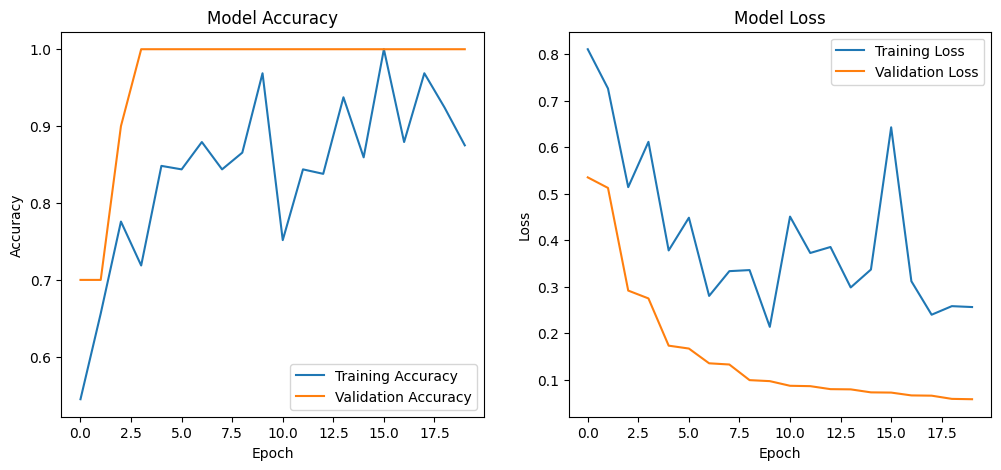

In [33]:
train_logs = {
    'accuracy': history.history['accuracy'] + history_fine.history['accuracy'],
    'val_accuracy': history.history['val_accuracy'] + history_fine.history['val_accuracy'],
    'loss': history.history['loss'] + history_fine.history['loss'],
    'val_loss': history.history['val_loss'] + history_fine.history['val_loss']}

for epoch, (acc, val_acc, loss, val_loss) in enumerate(zip(train_logs['accuracy'], train_logs['val_accuracy'], train_logs['loss'], train_logs['val_loss']), 1):
    print(f"Epoch {epoch} / {epochs * 2}: acc = {acc:.4f}, val_acc = {val_acc:.4f}, loss = {loss:.4f}, val_loss = {val_loss:.4f}")

# History

plt.figure(figsize = (12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_logs['accuracy'], label = 'Training Accuracy')
plt.plot(train_logs['val_accuracy'], label = 'Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_logs['loss'], label = 'Training Loss')
plt.plot(train_logs['val_loss'], label = 'Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

1. ***Model Accuracy (Left Plot):***

* *Training accuracy* increases but fluctuates.
* *Validation accuracy* quickly reaches 1 and stays there.
* May indicate *overfitting* or a *too small validation set*.

2. ***Model Loss (Right Plot):***

* *Training loss* decreases but is unstable.
* *Validation loss* steadily drops to near 0.
* Good validation performance, but *training instability* suggests possible overfitting.

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


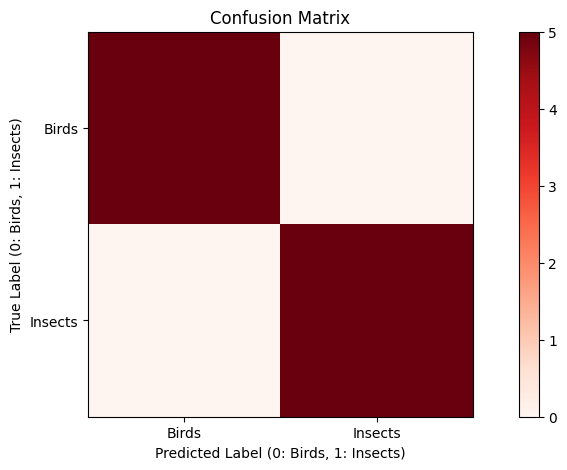

              precision    recall  f1-score   support

       Birds       1.00      1.00      1.00         5
     Insects       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [34]:
# Confusion Matrix

test_generator.reset()
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize = (12, 5))
plt.imshow(cm, interpolation = 'nearest', cmap = plt.cm.Reds)
plt.title('Confusion Matrix')
plt.colorbar()

plt.xlabel('Predicted Label (0: Birds, 1: Insects)')
plt.ylabel('True Label (0: Birds, 1: Insects)')

plt.xticks([0, 1], ['Birds', 'Insects'])
plt.yticks([0, 1], ['Birds', 'Insects'])

plt.show()

print(classification_report(true_classes, predicted_classes, target_names = ['Birds', 'Insects']))

1. **Confusion Matrix**

* *5 Birds* and *5 Insects*. It means all correctly classified.
* *0 misclassifications*.

2. **Classification Report**

* *100% precision, recall, and accuracy* for both classes.

As a result, they are great results, but test set is small, for that reason may not reflect real-world accuracy.

In [35]:
# Finally

***I WOULD LIKE TO EXPRESS MY SINCERE GRATITUDE FOR YOUR TIME AND CONSIDERATION***

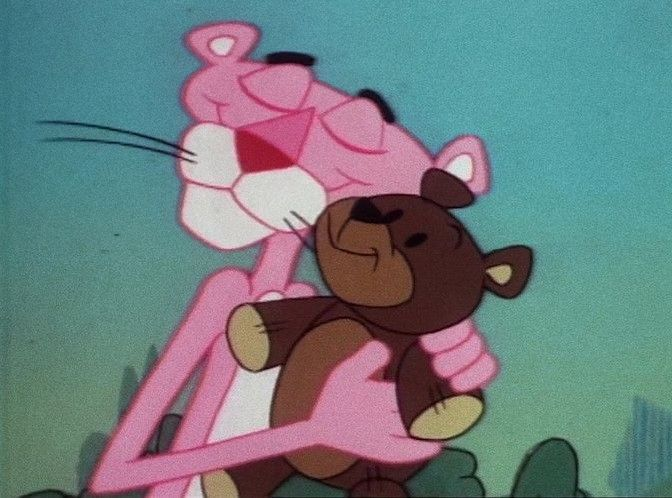